# Import packages and load data

In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn import model_selection
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from matplotlib import rc
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import ParameterGrid, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import r2_score
xscaler = MinMaxScaler()

In [2]:
file_path = '../../input_data/pspeo_master.xlsx'
model_output = 'grain'
# import data frame for pre-processing
df = pd.read_excel(file_path)
df.head()

,sample,solv_ratio,add_type,swell_ratio,gisaxs_domain,gisaxs_fwhm,afm_domain,afm_grain
0,I_A_AC,80/20,Chloronaphthalene,1.00,31.302630,0.003697,33.737303,0.0048
1,I_A025,80/20,Chloronaphthalene,1.25,33.805848,0.003136,35.151690,0.0047
2,I_A050,80/20,Chloronaphthalene,1.50,34.176062,0.002970,35.397797,0.0534
3,I_A075,80/20,Chloronaphthalene,1.75,34.383751,0.003451,34.603726,0.0425
4,I_A_100,80/20,Chloronaphthalene,2.00,31.674148,0.005122,33.786210,0.0244


# Data pre-processing

In [3]:
# Assign input variables and target variable, eliminating static valuesp
inputs = df.loc[:, ['solv_ratio', 'swell_ratio', 'add_type']]
target = df['afm_grain']

# Define mapping for solv_ratio
type_mapping = {100: 1.0, '90/10': 0.9, '80/20': 0.8, '70/30': 0.7, '60/40': 0.6, '50/50': 0.5}
inputs['solv_ratio'] = inputs['solv_ratio'].replace(type_mapping)

# Encode categorical input 'add_type'
le_addType = LabelEncoder()
inputs['add_type'] = le_addType.fit_transform(inputs['add_type'])

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(inputs, target, test_size=0.2, random_state=10)

# Scale the x data for better fitting
xscaler.fit(X_train)
X_train = xscaler.transform(X_train)
X_test = xscaler.transform(X_test)

# Define the model

Best CV R²: 0.2640877776539519
Test R²: 0.2594660978347906
Best Parameters: {'mlp__activation': 'relu', 'mlp__alpha': 1e-05, 'mlp__beta_1': 0.9, 'mlp__beta_2': 0.99, 'mlp__hidden_layer_sizes': (30, 10), 'mlp__learning_rate': 'constant', 'mlp__learning_rate_init': 0.001, 'mlp__solver': 'adam'}


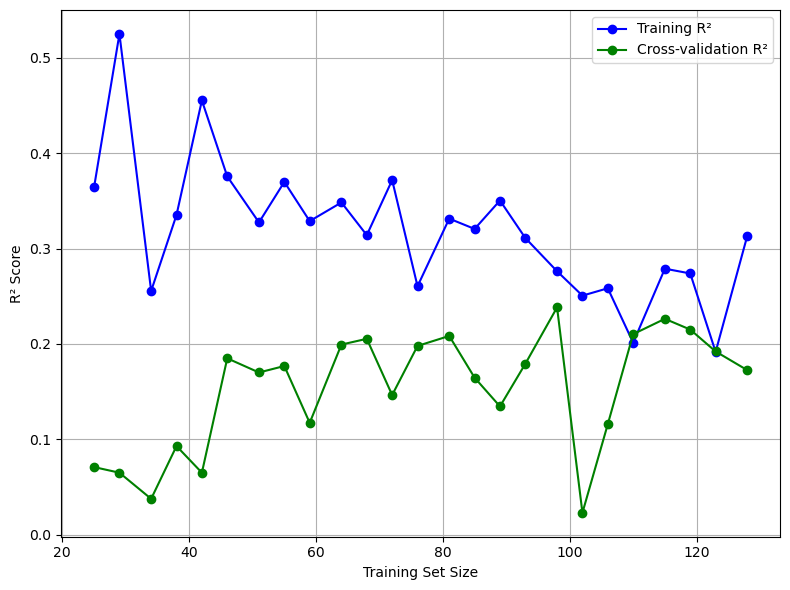

CPU times: user 197 ms, sys: 178 ms, total: 375 ms
Wall time: 1.44 s


In [4]:
%%time

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, ParameterGrid, learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Grid with adam + early stopping
param_grid = {
    'mlp__hidden_layer_sizes': [(30, 10)],
    'mlp__activation': ['relu'],
    'mlp__solver': ['adam'],
    'mlp__alpha': [1e-5],
    'mlp__learning_rate': ['constant'],
    'mlp__learning_rate_init': [0.001],
    'mlp__beta_1': [0.9],  # momentum-like parameter for adam
    'mlp__beta_2': [0.99],  # controls stability/speed tradeoff
}


RANDOM_SEED = 42
CV_FOLDS = 5

# Track best
best_model = None
best_params = None
best_cv_r2 = float('-inf')
best_test_r2 = None

# Grid search
for params in ParameterGrid(param_grid):
    # Strip "mlp__" prefix for MLPRegressor arguments
    mlp_kwargs = {k.replace("mlp__", ""): v for k, v in params.items()}

    model = make_pipeline(
        StandardScaler(),
        TransformedTargetRegressor(
            regressor=MLPRegressor(
                random_state=RANDOM_SEED,
                max_iter=10000,
                early_stopping=True,
                n_iter_no_change=10,
                validation_fraction=0.1,
                **mlp_kwargs
            ),
            transformer=StandardScaler()
        )
    )

    # CV performance only for selection
    cv_scores = cross_val_score(model, X_train, y_train, cv=CV_FOLDS, scoring='r2', n_jobs=-1)
    cv_r2 = np.mean(cv_scores)
    
    # Fit to compute test score
    model.fit(X_train, y_train)
    test_r2 = model.score(X_test, y_test)

    if cv_r2 > best_cv_r2:
        best_cv_r2 = cv_r2
        best_model = model
        best_params = params
        best_test_r2 = test_r2

print("Best CV R²:", best_cv_r2)
print("Test R²:", best_test_r2)
print("Best Parameters:", best_params)

# ------------------------------
# Learning curve
# ------------------------------
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=make_pipeline(
        StandardScaler(),
        TransformedTargetRegressor(
            regressor=MLPRegressor(
                random_state=RANDOM_SEED,
                max_iter=10000,
                early_stopping=True,
                n_iter_no_change=10,
                validation_fraction=0.1,
                **{k.replace("mlp__", ""): v for k, v in best_params.items()}
            ),
            transformer=StandardScaler()
        )
    ),
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.2, 1.0, 25),  # avoid tiny unstable sets
    cv=CV_FOLDS,
    scoring='r2',
    n_jobs=-1,
    shuffle=True,
    random_state=RANDOM_SEED
)

train_scores_mean = np.mean(train_scores, axis=1)
valid_scores_mean = np.mean(valid_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training R²')
plt.plot(train_sizes, valid_scores_mean, 'o-', color='green', label='Cross-validation R²')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

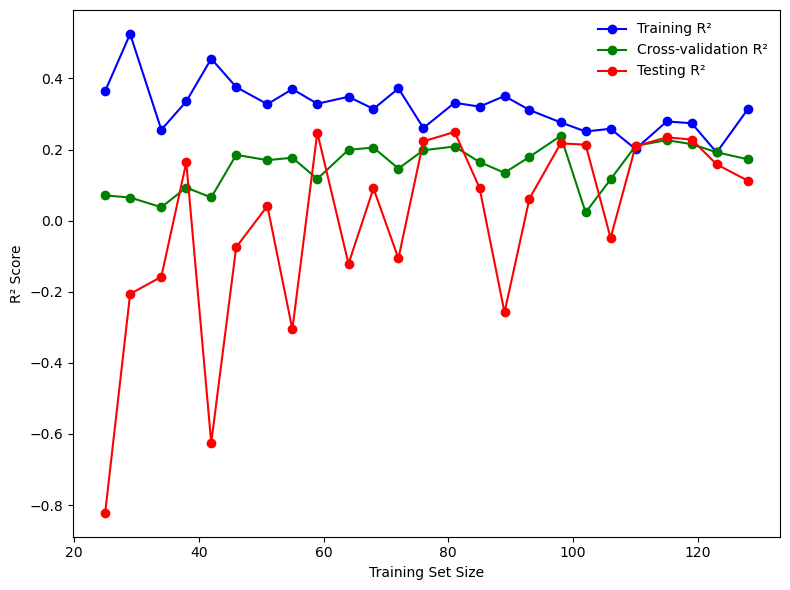

In [6]:
test_scores = []

for size in train_sizes:
    n_samples = int(size)

    # Sample subset of training data
    X_sub, y_sub = resample(X_train, y_train, replace=False, n_samples=n_samples, random_state=RANDOM_SEED)

    # Create MLP pipeline with best hyperparameters
    mlp_kwargs = {k.replace("mlp__", ""): v for k, v in best_params.items()}
    model = make_pipeline(
        StandardScaler(),
        TransformedTargetRegressor(
            regressor=MLPRegressor(
                random_state=RANDOM_SEED,
                max_iter=10000,
                early_stopping=True,
                n_iter_no_change=10,
                validation_fraction=0.1,
                **mlp_kwargs
            ),
            transformer=StandardScaler()
        )
    )

    # Fit on subset
    model.fit(X_sub, y_sub)

    # Evaluate on the fixed test set
    r2_test = model.score(X_test, y_test)
    test_scores.append(r2_test)

test_scores = np.array(test_scores)

# Plot all three curves
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training R²')
plt.plot(train_sizes, valid_scores_mean, 'o-', color='green', label='Cross-validation R²')
plt.plot(train_sizes, test_scores, 'o-', color='red', label='Testing R²')

plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.legend(loc='best', frameon=False)
plt.grid(False)
plt.tight_layout()
plt.savefig('learning_curve_with_test.png', dpi=500)
plt.show()

In [6]:
# Rebuild the best MLP model with pipeline
final_mlp_model = make_pipeline(
        StandardScaler(),
        TransformedTargetRegressor(
            regressor=MLPRegressor(
                random_state=RANDOM_SEED,
                max_iter=10000,
                early_stopping=True,
                n_iter_no_change=10,
                validation_fraction=0.1,
                **{k.replace("mlp__", ""): v for k, v in best_params.items()}
            ),
            transformer=StandardScaler()
        )
    )

# Fit to the full training data
final_mlp_model.fit(X_train, y_train)

# Evaluate on test set
test_r2 = final_mlp_model.score(X_test, y_test)
print("Final Test R²:", test_r2)

Final Test R²: 0.2594660978347906


In [7]:
train_r2 = final_mlp_model.score(X_train, y_train)
test_r2 = final_mlp_model.score(X_test, y_test)

print(f'Training r2: {train_r2}')
print(f'Testing r2: {test_r2}')

# Create an array for x values
x_len = len(y_test)
actual_x = np.arange(1, x_len+1)

# Define the output path for figures
output_path = f'../final_figs/{model_output}/'

Training r2: 0.29390931273670684
Testing r2: 0.2594660978347906


In [8]:
output_path = f'../final_figs/{model_output}/'

In [9]:
from joblib import dump, load

dump(final_mlp_model, f'{model_output}.joblib')

['grain.joblib']

In [10]:
mlp_train = final_mlp_model.predict(X_train)
mlp_test = final_mlp_model.predict(X_test)

# Visualize the results

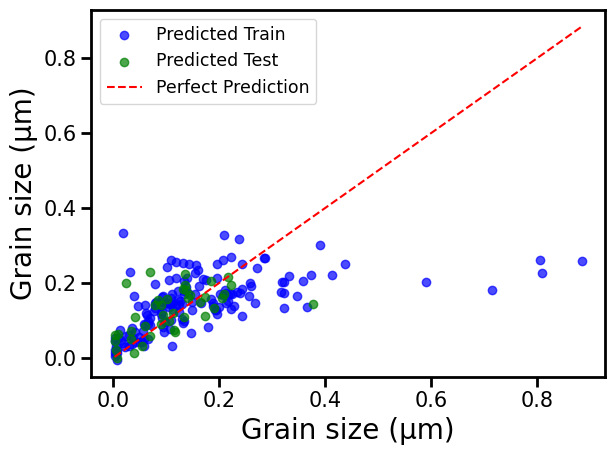

In [11]:
# Define the figure title
fig_title = f'{model_output}_avp.png'

# set formatting for plots
%matplotlib inline
# from matplotlib import cm
from matplotlib import rc
rc('text', usetex=False)
rc('mathtext', fontset='cm')
rc('xtick', labelsize=15)  
rc('xtick.major', size=7)   
rc('xtick.minor', size=4)
rc('xtick.major', width=2)
rc('xtick.minor', width=2)
rc('ytick.major', width=2)
rc('ytick.minor', width=2)
rc('ytick', labelsize=15)
rc('ytick.major', size=7)
rc('ytick.minor', size=4)
rc('axes', labelsize=15) 
rc('axes', linewidth=2) 
rc('font',family='sans serif')
rc('font', style='normal')
rc('font', weight='500')
rc('font', size='15')
rc('axes', labelweight='500')
rc('axes.spines', **{'right':True, 'top':True})   

# Create a scatter plot
plt.scatter(y_train, mlp_train, color='blue', label='Predicted Train', alpha=0.7)
plt.scatter(y_test, mlp_test, color='green', label='Predicted Test', alpha=0.7)

# Add a diagonal line for reference (perfect prediction)
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], linestyle='--', color='red', label='Perfect Prediction')

# Add labels and a legend
plt.xlabel('Grain size (\u03BCm)', fontsize='20')
plt.ylabel('Grain size (\u03BCm)', fontsize='20')

# Set legend background color to white
legend = plt.legend(fontsize='12.5')
legend.get_frame().set_facecolor('white')

# Set the background color to white
plt.gca().set_facecolor('white')

# Remove gridlines
plt.grid(False)

# Add tickmarks to x and y axes
plt.tick_params(axis='both', which='both', reset=True, top=False, right=False)

# # Add black borders to the grid
plt.gca().spines['top'].set_color('black')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().spines['right'].set_color('black')

# Show the plot
plt.tight_layout()
# plt.savefig(output_path + fig_title, format='png')
plt.show()

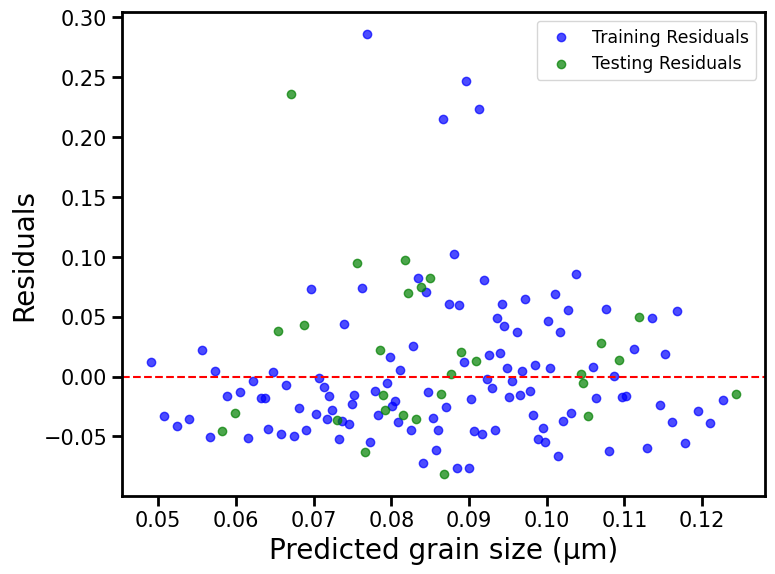

In [8]:
# Define the figure title
fig_title = f'{model_output}_residuals.png'

res_train = y_train - mpltrain
res_test = y_test - mpleval

# set formatting for plots
%matplotlib inline
rc('text', usetex=False)
rc('mathtext', fontset='cm')
rc('xtick', labelsize=15)  
rc('xtick.major', size=7)   
rc('xtick.minor', size=4)
rc('xtick.major', width=2)
rc('xtick.minor', width=2)
rc('ytick.major', width=2)
rc('ytick.minor', width=2)
rc('ytick', labelsize=15)
rc('ytick.major', size=7)
rc('ytick.minor', size=4)
rc('axes', labelsize=15) 
rc('axes', linewidth=2) 
rc('font',family='sans serif')
rc('font', style='normal')
rc('font', weight='500')
rc('font', size='15')
rc('axes', labelweight='500')
rc('axes.spines', **{'right':True, 'top':True})   

# Create a residuals plot
plt.figure(figsize=(8, 6))
plt.scatter(mpltrain, res_train, color='blue', alpha=0.7, label='Training Residuals')
plt.scatter(mpleval, res_test, color='green', alpha=0.7, label='Testing Residuals')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel("Predicted grain size (\u03BCm)", fontsize='20')
plt.ylabel("Residuals", fontsize='20')
# Set legend background color to white
legend = plt.legend(fontsize='12.5')
legend.get_frame().set_facecolor('white')

# Set the background color to white
plt.gca().set_facecolor('white')

# Remove gridlines
plt.grid(False)

# Add tickmarks to x and y axes
plt.tick_params(axis='both', which='both', reset=True, top=False, right=False)

# # Add black borders to the grid
plt.gca().spines['top'].set_color('black')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().spines['right'].set_color('black')

plt.grid(False)
plt.tight_layout()
plt.savefig(output_path + fig_title, format='png')
plt.show()

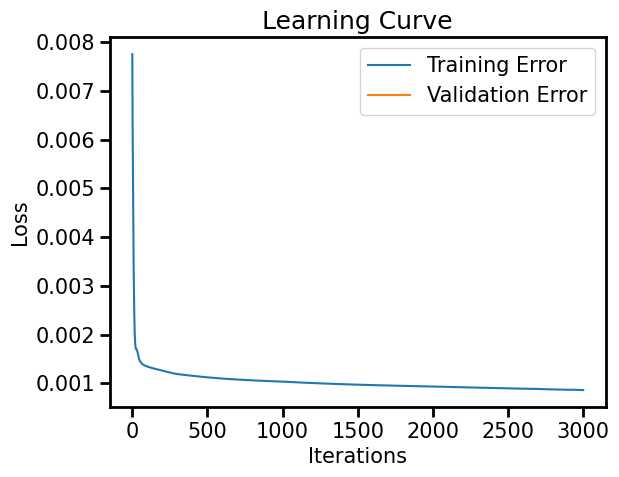

In [9]:
train_errors = []
val_errors = []

for i in range(mlp_regressor.max_iter):
    mlp_regressor.partial_fit(X_train, y_train)
    train_error = mlp_regressor.loss_
    train_errors.append(train_error)
    val_errors.append(mlp_regressor.validation_scores_)

    # Check for early stopping
    if mlp_regressor.early_stopping and (i > 0) and (val_errors[-1] > val_errors[-2]):
        break

# Plot the learning curve
plt.plot(np.arange(1, len(train_errors) + 1), train_errors, label='Training Error')
plt.plot(np.arange(1, len(val_errors) + 1), val_errors, label='Validation Error')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Learning Curve')
plt.legend()
plt.show()

In [10]:
from joblib import dump, load

dump(best, 'nn_grain.joblib')

['nn_grain.joblib']